<a href="https://colab.research.google.com/github/Virkhow/Test_Guide/blob/main/%D0%98%D0%B2%D0%AD_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Подключение нужных для работы моделей
import pandas as pd     # для чтения и записи табличных файлов
import numpy as np      # для математической обработки данных
import matplotlib.pyplot as plt # для построения графиков
import plotly.graph_objects as go # для построения интерактивных графиков


In [ ]:
# 2. Получение и чтение файла из облака
url = "https://drive.google.com/uc?export=download&id=1DZfg1OpDMYvICUBS_fLaeaPjiBtH2aee"

input_df = pd.read_csv(url, sep = ',')

input_df.head()

,Wind_power_MW,Solar_power_kW,Consumption_MW
0,65.655516,0.0000,34.70
1,69.111069,0.0000,32.79
2,72.134678,178.6368,33.09
3,75.590232,721.5360,33.63
4,68.247181,3752.5248,34.51


In [ ]:
# 3. Просмотр последних строк таблицы
input_df.tail()

,Wind_power_MW,Solar_power_kW,Consumption_MW
8755,128.719366,0.0,45.47
8756,129.583255,0.0,40.72
8757,130.447143,0.0,39.11
8758,132.606864,0.0,36.91
8759,134.766585,0.0,35.58


In [ ]:
# 4. Получение базовых статистических показателей
input_df.describe()

,Wind_power_MW,Solar_power_kW,Consumption_MW,SMA_5
count,8760.000000,8760.000000,8760.000000,8756.000000
mean,91.842674,1557.825929,31.154526,91.838555
std,38.617121,2384.385076,8.008808,36.511094
min,1.295833,0.000000,13.900000,11.835271
25%,63.927739,0.000000,26.380000,65.029197
50%,90.708278,0.000000,30.350000,90.103556
75%,116.624929,2468.332800,36.610000,115.329097
max,277.740109,8364.211200,56.290000,268.755670


In [ ]:
# 5. Построение графика временного ряда
# Вариант 6: Взять график выработки ВЭС и построить график простого скользящего среднего (SMA) по пяти точкам

# Расчет скользящего среднего по 5 точкам
input_df['SMA_5'] = input_df['Wind_power_MW'].rolling(window=5).mean()

# Интерактивный график
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=input_df.index,
    y=input_df['Wind_power_MW'],
    mode='lines',
    name='Выработка ВЭС',
    line=dict(color='blue', width=1)
))

fig.add_trace(go.Scatter(
    x=input_df.index,
    y=input_df['SMA_5'],
    mode='lines',
    name='SMA-5',
    line=dict(color='red', width=2)
))

fig.update_layout(
    title='Выработка ВЭС и простое скользящее среднее (SMA-5)',
    xaxis_title='Время (индекс)',
    yaxis_title='Мощность, МВт',
    width=1000,
    height=500
)

fig.show()

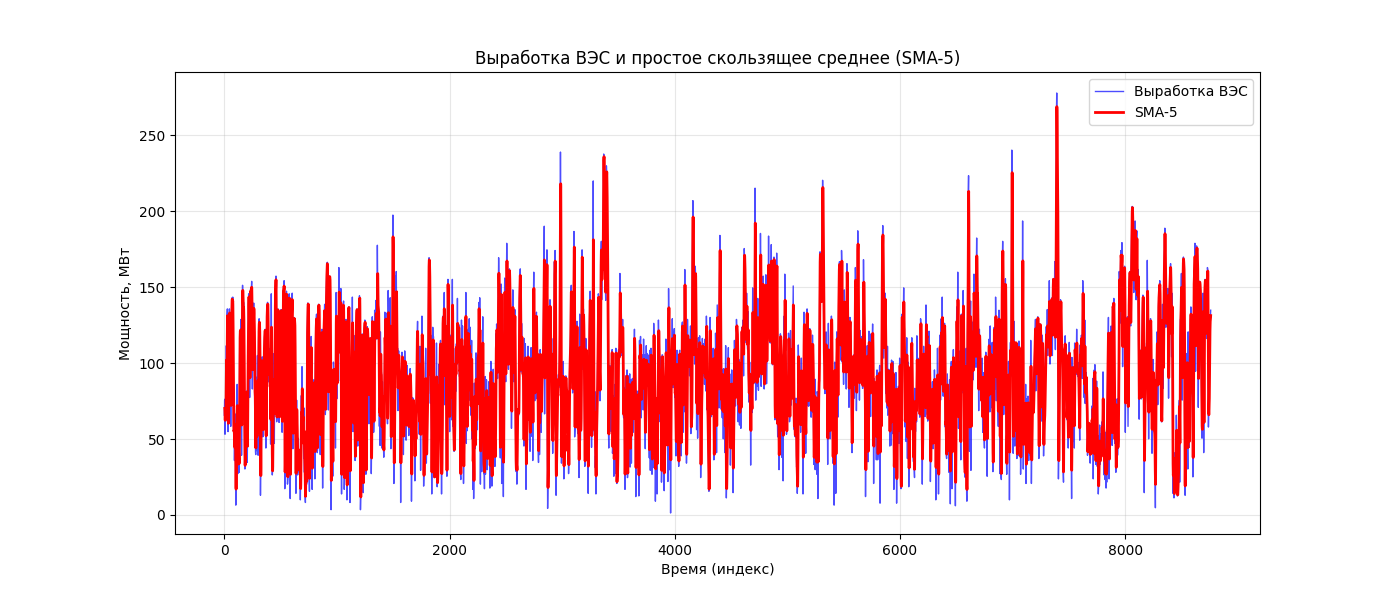

In [ ]:
# 6. Сохранение графика как изображение
from google.colab import files
files.download("wind_sma_graph.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>